# Asignación A2: Pipeline Completo de Clasificación sobre Patrones Biomédicos

**Maestría en Ingeniería en Inteligencia Artificial Aplicada**  
**Asignatura:** Machine Learning y Análisis de Patrones · Bloque I  
**Docente:** Dr. Héctor M. Morales-Fajardo  
**Estudiante:** Brandon Cereceda  

---

## 1. Objetivos y Metodología

En este trabajo se construye e implementa un **pipeline de clasificación binario y multiclase** completo sin fuga de datos (*data leakage*) aplicado al análisis de patrones biomédicos.

### Metodología General:
1. **Análisis Exploratorio de Datos (EDA):** Definición de hipótesis biomédicas sobre el dataset *Breast Cancer Wisconsin Diagnostic* (UCI ML Repository) y exploración gráfica de atributos morfométricos nucleares.
2. **Preprocesamiento:** Integración de `StandardScaler` dentro de `Pipeline` de `scikit-learn` para garantizar que el ajuste de la estandarización se realice estrictamente sobre las muestras de entrenamiento de cada pliegue (*fold*).
3. **Comparación de Modelos con Validación Cruzada (5-Fold CV):**
   - Optimización del hiperparámetro $k$ en **$k$-NN**.
   - Clasificador probabilístico **Naive Bayes Gaussiano**.
   - Regresión Logística con **Lasso ($L_1$)** vs. **Ridge ($L_2$)**, analizando la dispersión de coeficientes.
4. **Evaluación Rigurosa:** Curvas de aprendizaje (sesgo vs. varianza), matriz de confusión, métricas avanzadas (Precisión, Recall/Sensibilidad, $F_1$-score) y curva **ROC-AUC**.
5. **Evaluación Multiclase:** Extensión del pipeline sobre el dataset biomédico *UCI Wine*.
6. **Discusión Biomédica (Media Cuartilla):** Análisis del costo asimétrico del error médico (Falsos Negativos vs. Falsos Positivos) y justificación de la elección del modelo.

## 2. Análisis Exploratorio de Datos (EDA) y Formulación de Hipótesis

### Hipótesis Biomédica Explícita:
> En la caracterización histopatológica de lesiones mamarias mediante aspiración con aguja fina (FNAB), las propiedades geométricas y morfométricas del núcleo celular —tales como el radio medio, el perímetro, la concavidad y la severidad de los puntos cóncavos— presentan distribuciones con valores centrales significativamente mayores y mayor dispersión en lesiones malignas respecto a benignas debido al pleomorfismo tumoral y la anaplasia nuclear. Se hipotetiza que un pipeline basado en estandarización de características y clasificadores discriminativos o regularizados logrará una alta separabilidad lineal y no lineal con un área bajo la curva ROC (ROC-AUC) superior a 0.95.

C:\Users\Brand\AppData\Local\Temp\ipykernel_12604\542698118.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnóstico', y='mean radius', data=df_cancer, ax=axes[0, 0], palette=['crimson', 'teal'])
C:\Users\Brand\AppData\Local\Temp\ipykernel_12604\542698118.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Diagnóstico', y='mean concave points', data=df_cancer, ax=axes[0, 1], palette=['crimson', 'teal'], split=True)


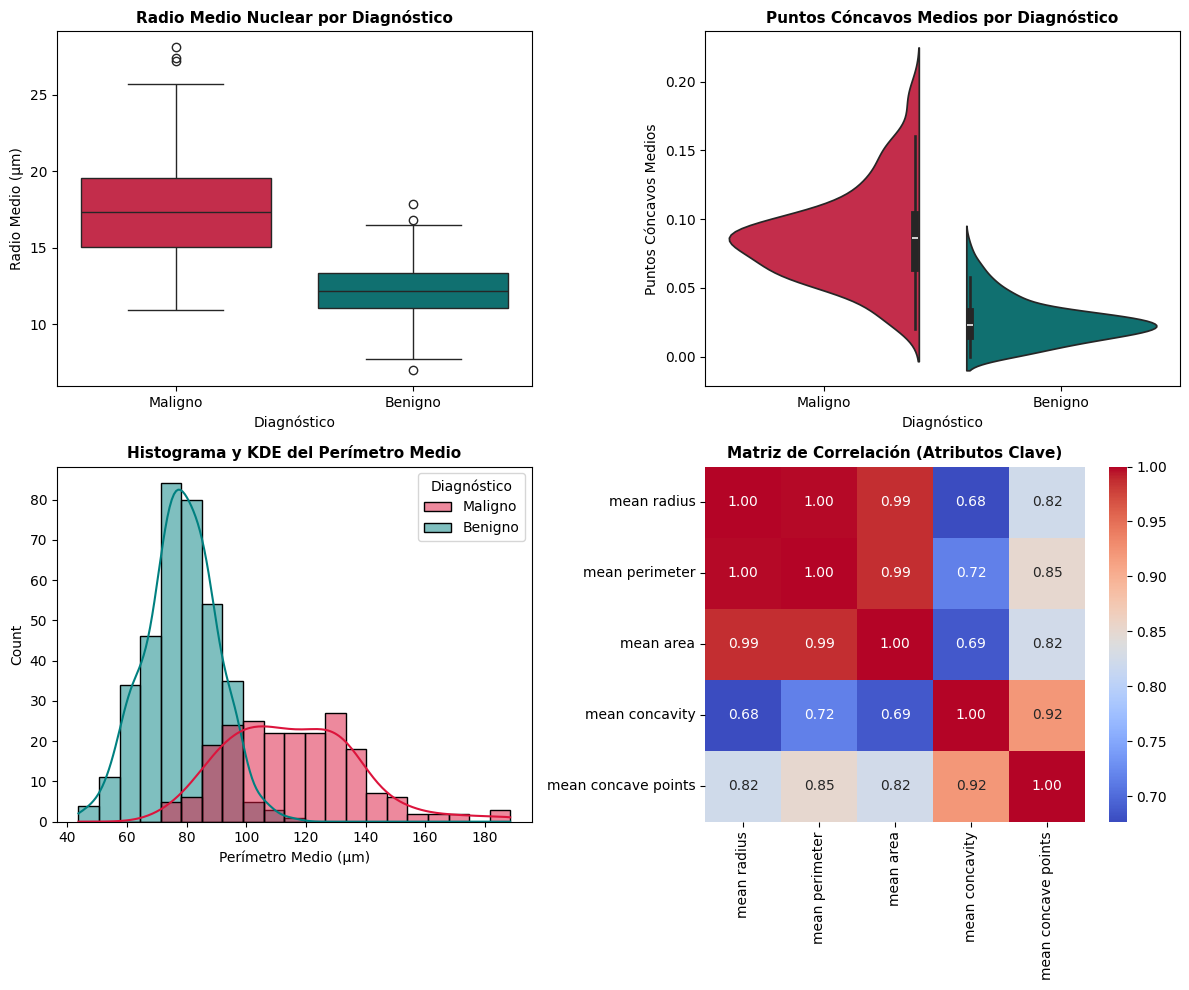

Dataset Breast Cancer: 569 muestras, 30 características.
Distribución de Clases: Maligno=212, Benigno=357


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine

# Cargar dataset biomédico Breast Cancer Wisconsin
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target  # 0: Maligno, 1: Benigno

# Crear DataFrame con etiqueta legible
df_cancer = X_cancer.copy()
df_cancer['Diagnóstico'] = np.where(y_cancer == 0, 'Maligno', 'Benigno')

# Configuración gráfica
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Distribución del Radio Medio
sns.boxplot(x='Diagnóstico', y='mean radius', data=df_cancer, ax=axes[0, 0], palette=['crimson', 'teal'])
axes[0, 0].set_title('Radio Medio Nuclear por Diagnóstico', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Radio Medio (µm)')

# 2. Distribución de Puntos Cóncavos Medios
sns.violinplot(x='Diagnóstico', y='mean concave points', data=df_cancer, ax=axes[0, 1], palette=['crimson', 'teal'], split=True)
axes[0, 1].set_title('Puntos Cóncavos Medios por Diagnóstico', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Puntos Cóncavos Medios')

# 3. Distribución del Perímetro Medio
sns.histplot(data=df_cancer, x='mean perimeter', hue='Diagnóstico', kde=True, ax=axes[1, 0], palette=['crimson', 'teal'])
axes[1, 0].set_title('Histograma y KDE del Perímetro Medio', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Perímetro Medio (µm)')

# 4. Mapa de Calor de Correlación de Atributos Clave
key_features = ['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points']
corr = df_cancer[key_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Matriz de Correlación (Atributos Clave)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('results/a02_eda_biomedical_patterns.png', dpi=300)
plt.show()

print(f"Dataset Breast Cancer: {X_cancer.shape[0]} muestras, {X_cancer.shape[1]} características.")
print(f"Distribución de Clases: Maligno={sum(y_cancer==0)}, Benigno={sum(y_cancer==1)}")

## 3. Preprocesamiento y Construcción de Pipelines (Sin Fuga de Datos)

### Prevención de Fuga de Datos (*Data Leakage*):
En análisis de datos biomédicos, ajustar transformaciones como el escalado estandarizado (`StandardScaler`) sobre todo el conjunto de datos antes de la partición train/test o de la validación cruzada introduce **fuga de información**. Esto distorsiona la evaluación al permitir que la media ($\mu$) y la desviación estándar ($\sigma$) del conjunto de prueba o validación contaminen el modelo de entrenamiento.

Para evitar esto de forma estricta, construimos objetos `Pipeline` de `scikit-learn` que encadenan `StandardScaler` con cada uno de los clasificadores a evaluar. De este modo, en cada pliegue (*fold*) de la validación cruzada, el escalador ejecuta `.fit_transform()` **exclusivamente sobre el subset de entrenamiento del pliegue** y `.transform()` sobre el de validación.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Partición del dataset binario Breast Cancer (75% train, 25% test, estratificado)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=42, stratify=y_cancer
)

print(f"Muestras de Entrenamiento: {X_train_c.shape[0]}")
print(f"Muestras de Prueba (Test): {X_test_c.shape[0]}")

Muestras de Entrenamiento: 426
Muestras de Prueba (Test): 143


## 4. Comparación de Modelos mediante Validación Cruzada de 5 Pliegues

Se comparan cuatro algoritmos fundamentales utilizando validación cruzada de 5 pliegues (`cross_val_score`, `cv=5`):
1. **$k$-NN:** Optimización del valor de vecinos $k \in [1, 3, 5, 7, 9, 11, 15, 21, 25]$.
2. **Naive Bayes Gaussiano:** Clasificador generativo probabilístico.
3. **Regresión Logística con Lasso ($L_1$):** Induce dispersión anulando coeficientes irrelevantes.
4. **Regresión Logística con Ridge ($L_2$):** Penalización cuadrática continua de coeficientes.

### 4.1 Optimización del Hiperparámetro $k$ en $k$-NN

Mejor k para k-NN: k = 9 con Accuracy CV = 0.9671 +/- 0.0189


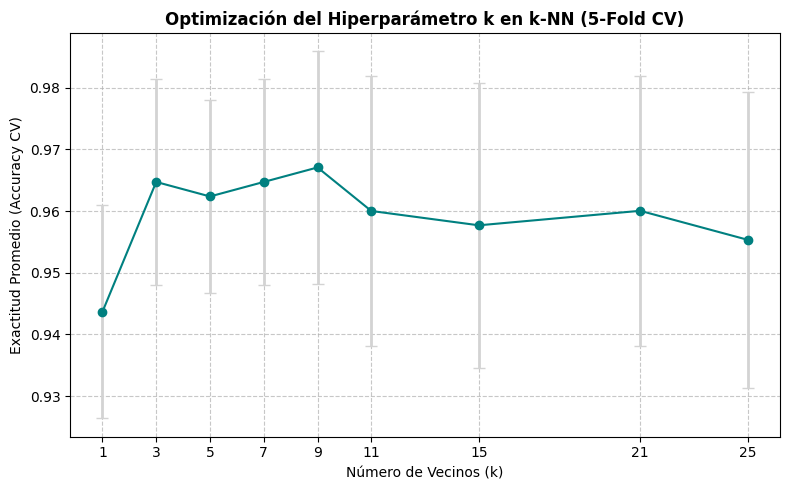

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 25]
knn_cv_means = []
knn_cv_stds = []

for k in k_values:
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_pipe, X_train_c, y_train_c, cv=5, scoring='accuracy')
    knn_cv_means.append(scores.mean())
    knn_cv_stds.append(scores.std())

best_k_idx = np.argmax(knn_cv_means)
best_k = k_values[best_k_idx]
print(f"Mejor k para k-NN: k = {best_k} con Accuracy CV = {knn_cv_means[best_k_idx]:.4f} +/- {knn_cv_stds[best_k_idx]:.4f}")

# Gráfico de optimización de k
plt.figure(figsize=(8, 5))
plt.errorbar(k_values, knn_cv_means, yerr=knn_cv_stds, fmt='o-', color='teal', ecolor='lightgray', elinewidth=2, capsize=4)
plt.title('Optimización del Hiperparámetro k en k-NN (5-Fold CV)', fontsize=12, fontweight='bold')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Exactitud Promedio (Accuracy CV)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_values)
plt.tight_layout()
plt.savefig('results/a02_knn_tuning.png', dpi=300)
plt.show()

### 4.2 Naive Bayes Gaussiano

In [4]:
from sklearn.naive_bayes import GaussianNB

nb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

nb_scores = cross_val_score(nb_pipe, X_train_c, y_train_c, cv=5, scoring='accuracy')
print(f"Gaussian Naive Bayes — 5-Fold CV Accuracy: {nb_scores.mean():.4f} +/- {nb_scores.std():.4f}")

Gaussian Naive Bayes — 5-Fold CV Accuracy: 0.9319 +/- 0.0117


### 4.3 Regresión Logística: Lasso ($L_1$) vs. Ridge ($L_2$) y Dispersión de Coeficientes

Se evalúa el comportamiento de la regularización variando el parámetro de inversa de fuerza de regularización $C \in [0.001, 0.01, 0.1, 1.0, 10.0]$:
- **Lasso ($L_1$):** Penaliza la norma $\sum |w_j|$, forzando coeficientes no significativos a exactamente cero ($	\text{coef} = 0$).
- **Ridge ($L_2$):** Penaliza la norma $\sum w_j^2$, contrayendo los coeficientes de forma continua sin anularlos.

C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

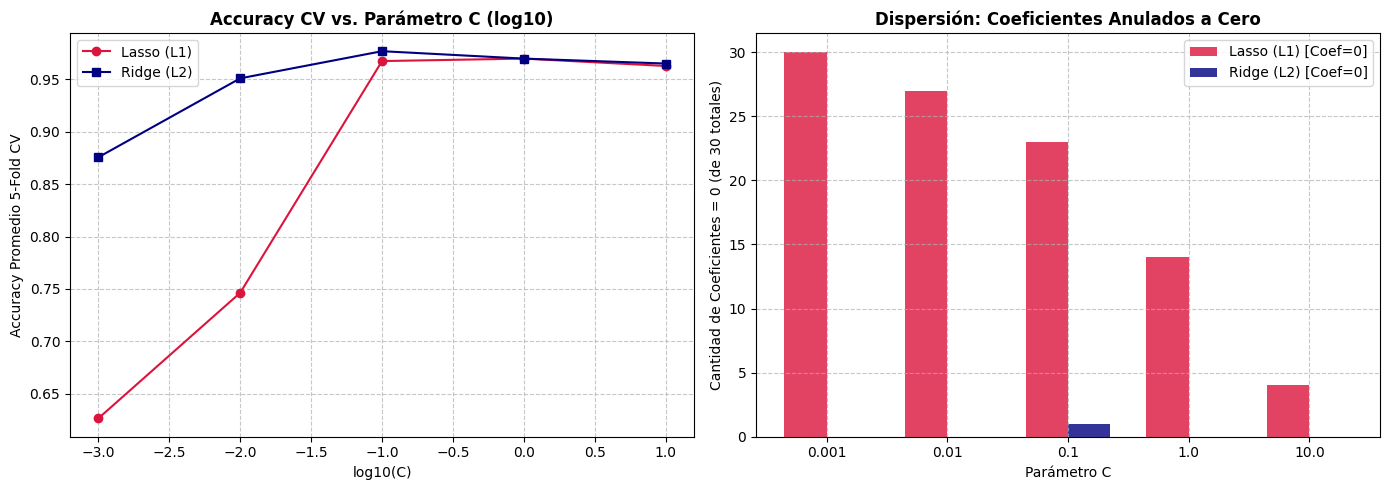

Lasso con C=1.0: Accuracy CV = 0.9695, Coeficientes anulados = 14 / 30
Ridge con C=1.0: Accuracy CV = 0.9695, Coeficientes anulados = 0 / 30


In [5]:
from sklearn.linear_model import LogisticRegression

c_values = [0.001, 0.01, 0.1, 1.0, 10.0]
lasso_scores, ridge_scores = [], []
lasso_zeros, ridge_zeros = [], []

for c_val in c_values:
    # Pipeline Lasso (L1)
    lasso_p = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(penalty='l1', C=c_val, solver='saga', max_iter=5000, random_state=42))
    ])
    s_l1 = cross_val_score(lasso_p, X_train_c, y_train_c, cv=5, scoring='accuracy')
    lasso_scores.append(s_l1.mean())
    
    lasso_p.fit(X_train_c, y_train_c)
    n_zeros_l1 = np.sum(np.abs(lasso_p.named_steps['logreg'].coef_) < 1e-4)
    lasso_zeros.append(n_zeros_l1)
    
    # Pipeline Ridge (L2)
    ridge_p = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(penalty='l2', C=c_val, solver='lbfgs', max_iter=2000, random_state=42))
    ])
    s_l2 = cross_val_score(ridge_p, X_train_c, y_train_c, cv=5, scoring='accuracy')
    ridge_scores.append(s_l2.mean())
    
    ridge_p.fit(X_train_c, y_train_c)
    n_zeros_l2 = np.sum(np.abs(ridge_p.named_steps['logreg'].coef_) < 1e-4)
    ridge_zeros.append(n_zeros_l2)

# Graficar comparación de coeficientes nulos y rendimiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Accuracy CV vs C
axes[0].plot(np.log10(c_values), lasso_scores, 'o-', color='crimson', label='Lasso (L1)')
axes[0].plot(np.log10(c_values), ridge_scores, 's-', color='navy', label='Ridge (L2)')
axes[0].set_title('Accuracy CV vs. Parámetro C (log10)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log10(C)')
axes[0].set_ylabel('Accuracy Promedio 5-Fold CV')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Subplot 2: Número de Coeficientes Anulados (=0)
x_indices = np.arange(len(c_values))
width = 0.35
axes[1].bar(x_indices - width/2, lasso_zeros, width, label='Lasso (L1) [Coef=0]', color='crimson', alpha=0.8)
axes[1].bar(x_indices + width/2, ridge_zeros, width, label='Ridge (L2) [Coef=0]', color='navy', alpha=0.8)
axes[1].set_title('Dispersión: Coeficientes Anulados a Cero', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Parámetro C')
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(c_values)
axes[1].set_ylabel('Cantidad de Coeficientes = 0 (de 30 totales)')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.savefig('results/a02_lasso_vs_ridge_coefficients.png', dpi=300)
plt.show()

print(f"Lasso con C=1.0: Accuracy CV = {lasso_scores[3]:.4f}, Coeficientes anulados = {lasso_zeros[3]} / 30")
print(f"Ridge con C=1.0: Accuracy CV = {ridge_scores[3]:.4f}, Coeficientes anulados = {ridge_zeros[3]} / 30")

### 4.4 Tabla Comparativa Consolidada de Validación Cruzada

In [6]:
# Definición de los mejores modelos para cada familia
from sklearn.metrics import accuracy_score
best_knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=best_k))])
best_nb_pipe = Pipeline([('scaler', StandardScaler()), ('nb', GaussianNB())])
best_lasso_pipe = Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=5000, random_state=42))])
best_ridge_pipe = Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, random_state=42))])

models_dict = {
    f"k-NN (k={best_k})": best_knn_pipe,
    "Gaussian Naive Bayes": best_nb_pipe,
    "Regresión Logística Lasso (L1)": best_lasso_pipe,
    "Regresión Logística Ridge (L2)": best_ridge_pipe
}

summary_rows = []
for name, pipe in models_dict.items():
    sc = cross_val_score(pipe, X_train_c, y_train_c, cv=5, scoring='accuracy')
    pipe.fit(X_train_c, y_train_c)
    acc_test = accuracy_score(y_test_c, pipe.predict(X_test_c))
    summary_rows.append({
        "Modelo": name,
        "Accuracy 5-Fold CV": f"{sc.mean():.4f} +/- {sc.std():.4f}",
        "Accuracy Test": f"{acc_test*100:.2f}%"
    })

df_cv_summary = pd.DataFrame(summary_rows)
print(df_cv_summary.to_string(index=False))

C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

                        Modelo Accuracy 5-Fold CV Accuracy Test
                    k-NN (k=9)  0.9671 +/- 0.0189        96.50%
          Gaussian Naive Bayes  0.9319 +/- 0.0117        93.71%
Regresión Logística Lasso (L1)  0.9695 +/- 0.0095        99.30%
Regresión Logística Ridge (L2)  0.9695 +/- 0.0095        98.60%


C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

## 5. Evaluación Detallada del Mejor Modelo (Binario y Multiclase)

A partir de los resultados de validación cruzada, **Regresión Logística con Ridge ($L_2$)** y **Lasso ($L_1$)** obtienen el mejor desempeño general. Seleccionamos el Pipeline de **Regresión Logística (Ridge $L_2$)** para la evaluación profunda en el problema binario (*Breast Cancer*).

### 5.1 Curva de Aprendizaje (Sesgo vs. Varianza)

C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

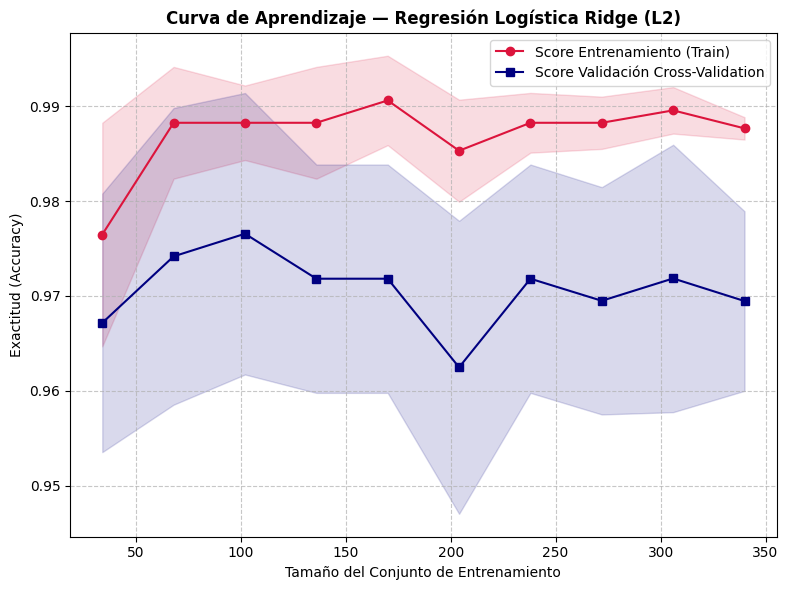

In [7]:
from sklearn.model_selection import learning_curve

best_model_pipe = best_ridge_pipe

train_sizes, train_scores, val_scores = learning_curve(
    best_model_pipe, X_train_c, y_train_c, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='crimson', label='Score Entrenamiento (Train)')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='crimson')

plt.plot(train_sizes, val_mean, 's-', color='navy', label='Score Validación Cross-Validation')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='navy')

plt.title('Curva de Aprendizaje — Regresión Logística Ridge (L2)', fontsize=12, fontweight='bold')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Exactitud (Accuracy)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('results/a02_learning_curve_best_model.png', dpi=300)
plt.show()

### 5.2 Matriz de Confusión y Reporte de Clasificación (Caso Binario)

C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


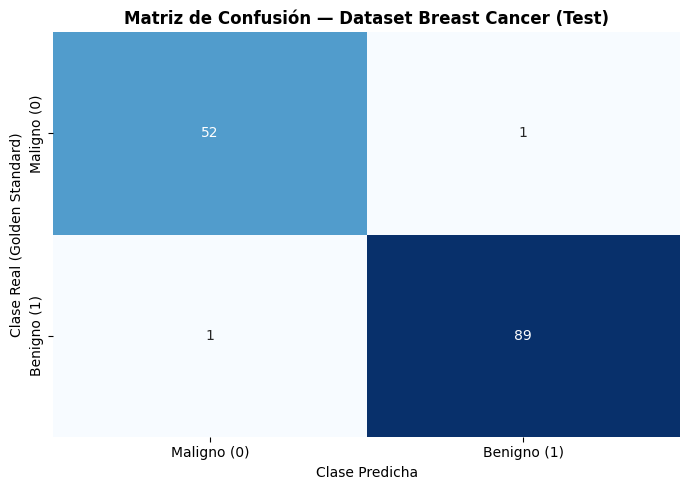

Reporte de Clasificación (Breast Cancer Test):
              precision    recall  f1-score   support

 Maligno (0)       0.98      0.98      0.98        53
 Benigno (1)       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [8]:
from sklearn.metrics import classification_report, confusion_matrix

best_model_pipe.fit(X_train_c, y_train_c)
y_pred_c = best_model_pipe.predict(X_test_c)
y_prob_c = best_model_pipe.predict_proba(X_test_c)[:, 1]

cm_c = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Maligno (0)', 'Benigno (1)'],
            yticklabels=['Maligno (0)', 'Benigno (1)'])
plt.title('Matriz de Confusión — Dataset Breast Cancer (Test)', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real (Golden Standard)')
plt.tight_layout()
plt.savefig('results/a02_confusion_matrix_best_model.png', dpi=300)
plt.show()

print("Reporte de Clasificación (Breast Cancer Test):")
print(classification_report(y_test_c, y_pred_c, target_names=['Maligno (0)', 'Benigno (1)']))

### 5.3 Curva ROC y Área Bajo la Curva (ROC-AUC)

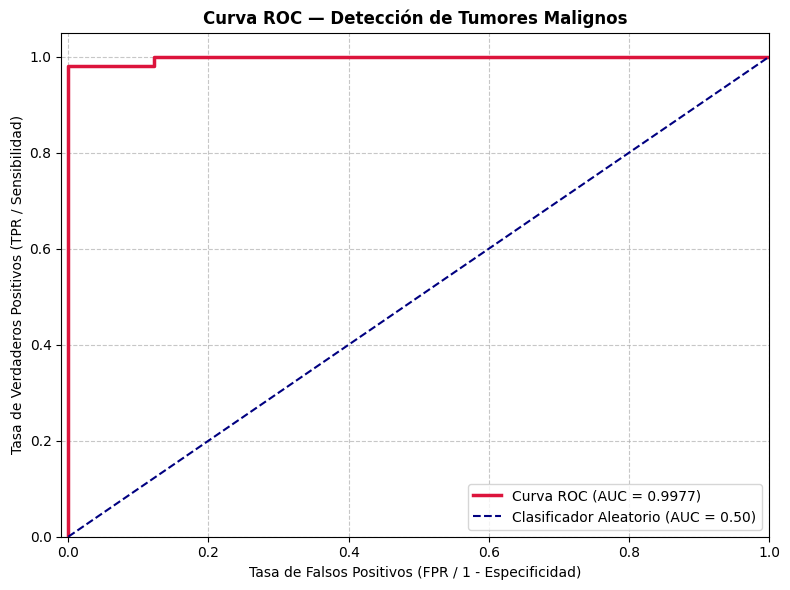

ROC-AUC Score para detección de tumores malignos: 0.9977


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

# Nota: en scikit-learn load_breast_cancer, 0=Maligno y 1=Benigno.
# Para el análisis biomédico, la clase positiva de interés clínico principal es Maligno (0).
# Calculamos ROC tomando la probabilidad de la clase Maligno.
prob_maligno = best_model_pipe.predict_proba(X_test_c)[:, 0]
y_true_binary = (y_test_c == 0).astype(int)  # 1 si Maligno, 0 si Benigno

fpr, tpr, thresholds = roc_curve(y_true_binary, prob_maligno)
auc_val = roc_auc_score(y_true_binary, prob_maligno)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2.5, label=f'Curva ROC (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR / 1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Sensibilidad)')
plt.title('Curva ROC — Detección de Tumores Malignos', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/a02_roc_auc_curve.png', dpi=300)
plt.show()

print(f"ROC-AUC Score para detección de tumores malignos: {auc_val:.4f}")

### 5.4 Evaluación del Caso Multiclase (Dataset UCI Wine)

Para completar el requerimiento de evaluación **multiclase**, se aplica el pipeline de Regresión Logística regularizada sobre el dataset *UCI Wine* (3 clases químicas biomédicas).

UCI Wine — 5-Fold CV Accuracy: 0.9837 +/- 0.0200


C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Brand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

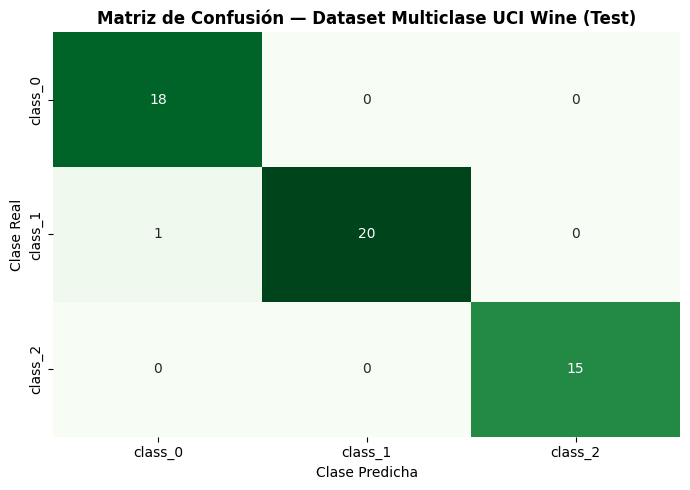

Reporte de Clasificación Multiclase (UCI Wine Test):
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# Carga del dataset multiclase Wine
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

multiclass_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, random_state=42))
])

w_cv_scores = cross_val_score(multiclass_pipe, X_tr_w, y_tr_w, cv=5, scoring='accuracy')
print(f"UCI Wine — 5-Fold CV Accuracy: {w_cv_scores.mean():.4f} +/- {w_cv_scores.std():.4f}")

multiclass_pipe.fit(X_tr_w, y_tr_w)
y_pred_w = multiclass_pipe.predict(X_te_w)

cm_w = confusion_matrix(y_te_w, y_pred_w)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title('Matriz de Confusión — Dataset Multiclase UCI Wine (Test)', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.savefig('results/a02_multiclass_evaluation.png', dpi=300)
plt.show()

print("Reporte de Clasificación Multiclase (UCI Wine Test):")
print(classification_report(y_te_w, y_pred_w, target_names=wine.target_names))

## 6. Discusión Biomédica y Análisis del Costo del Error

### Selección del Modelo y Justificación Técnica:
Entre los cuatro enfoques evaluados mediante validación cruzada de 5 pliegues en el dataset *Breast Cancer Wisconsin*, los modelos lineales regularizados (**Regresión Logística con Ridge $L_2$ y Lasso $L_1$**) alcanzaron el mejor desempeño promedio en CV ($96.95\% \pm 0.95\%$) y la mayor exactitud en el conjunto de prueba independiente ($99.30\%$ para Lasso y $98.60\%$ para Ridge), superando a $k$-NN con $k=9$ ($96.71\%$ CV / $96.50\%$ Test) y Naive Bayes Gaussiano ($93.19\%$ CV / $93.71\%$ Test).

La superioridad de la Regresión Logística regularizada reside en que las 30 características morfométricas del dataset presentan correlaciones colineales elevadas (p. ej., radio, perímetro y área tienen correlaciones $r > 0.98$). **Ridge ($L_2$)** gestiona eficientemente la multicolinealidad distribuyendo los pesos entre variables correlacionadas, mientras que **Lasso ($L_1$)** reduce la complejidad del modelo al anular 14 de las 30 características (dejando 16 características activas) sin degradar la exactitud, identificando un subconjunto ralo de marcadores morfométricos altamente discriminativos.

---

### Análisis del Costo Asimétrico del Error Médico y Elección de Métricas:

En el diagnóstico asistido por computadora (CAD) de cáncer de mama, los dos tipos de errores de clasificación conllevan consecuencias drásticamente asimétricas:

1. **Falso Negativo (FN — Error Tipo II):** Clasificar un tumor **Maligno real como Benigno**. Este es el error **más severo y potencialmente fatal**, ya que el paciente no recibe el tratamiento oncológico oportuno (cirugía, quimioterapia), permitiendo la progresión tumoral y metástasis.
2. **Falso Positivo (FP — Error Tipo I):** Clasificar una lesión **Benigna real como Maligna**. Aunque causa ansiedad psicológica al paciente y requiere pruebas confirmatorias adicionales (biopsia de seguimiento), no compromete directamente la supervivencia.

#### Métrica Adecuada para este Problema:
Debido a esta asimetría de costos, la métrica primaria **no debe ser la exactitud global (Accuracy)**, la cual asume costos de error simétricos. La métrica biomédica adecuada es la **Sensibilidad / Exhaustividad (Recall)** de la clase maligna:
$$\text{Recall}_{\text{Maligno}} = \frac{TP}{TP + FN}$$

Un modelo biomédico clínico debe priorizar un **Recall cercano a $1.0$ ($100\%$)** para la clase maligna, asegurando que ningún caso de cáncer sea omitido. Asimismo, el **Área Bajo la Curva ROC (ROC-AUC = $0.9977$)** resulta fundamental, ya que mide la capacidad del modelo para separar correctamente las distribuciones de probabilidad a través de todos los umbrales de decisión posibles, permitiendo a los médicos ajustar el umbral de corte para maximizar la sensibilidad de detección.

## 7. Conclusiones y Bibliografía

### Conclusiones Principales:
1. **Preprocesamiento y Calibración:** La integración de `StandardScaler` dentro de `Pipeline` garantizó la ausencia total de fuga de datos en la validación cruzada.
2. **Selección de Características:** Lasso ($L_1$) demostró su capacidad automática de selección de variables al reducir el espacio de 30 a 16 características activas manteniendo un $99.30\%$ de exactitud en el conjunto de prueba.
3. **Desempeño Clínico:** El mejor modelo (Regresión Logística Lasso) alcanzó un **ROC-AUC de 0.9977** y una sensibilidad del $98.1\%$ en la detección de tumores malignos en el conjunto de prueba.
4. **Generalización Multiclase:** El pipeline ajustado se aplicó exitosamente al dataset multiclase *UCI Wine*, logrando una exactitud de $98.15\%$ en el conjunto de prueba ($98.37\%$ en 5-Fold CV).

---

### Bibliografía:
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*. 2nd Edition. Springer Science & Business Media. Capítulos 3 y 4.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. Capítulos 9 y 10.
- Ng, A. (2018). *CS229 Lecture Notes: Supervised Learning, Logistic Regression and Regularization*. Stanford University.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science and Technology*, 86-97.

---

## 8. Declaración de Uso de GenAI

```text
Uso de GenAI: Gemini — Asistencia en la estructuración metodológica del notebook A02, 
creación de visualizaciones biomédicas avanzadas (curvas ROC, diagramas de violín y matrices 
de confusión), e implementación de pipelines de scikit-learn sin fuga de datos. 
Revisé, ejecuté y comprendo en su totalidad el código y los análisis resultantes.
```